In [ ]:
import requests
import json
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
headers = {'User-Agent': 'BITS-Pilani-Research-Project research@example.com'}
response = requests.get('https://www.sec.gov/files/company_tickers.json', headers=headers)
tickers_data = response.json()

for key, value in tickers_data.items():
    if value['ticker'] == 'GS':
        print(value)

{'cik_str': 886982, 'ticker': 'GS', 'title': 'GOLDMAN SACHS GROUP INC'}


In [ ]:
cik_padded = str(886982).zfill(10)  # SEC requires 10-digit zero-padded CIK
url = f'https://data.sec.gov/submissions/CIK{cik_padded}.json'
response = requests.get(url, headers=headers)
filings_data = response.json()
print(filings_data.keys())

dict_keys(['cik', 'entityType', 'sic', 'sicDescription', 'ownerOrg', 'insiderTransactionForOwnerExists', 'insiderTransactionForIssuerExists', 'name', 'tickers', 'exchanges', 'ein', 'lei', 'description', 'website', 'investorWebsite', 'category', 'fiscalYearEnd', 'stateOfIncorporation', 'stateOfIncorporationDescription', 'addresses', 'phone', 'flags', 'formerNames', 'filings'])


In [ ]:
print(filings_data['filings'].keys())
recent = filings_data['filings']['recent']
print(recent.keys())

dict_keys(['recent', 'files'])
dict_keys(['accessionNumber', 'filingDate', 'reportDate', 'acceptanceDateTime', 'act', 'form', 'fileNumber', 'filmNumber', 'items', 'core_type', 'size', 'isXBRL', 'isInlineXBRL', 'isXBRLNumeric', 'primaryDocument', 'primaryDocDescription'])


In [ ]:
forms = recent['form']
dates = recent['filingDate']
accession_numbers = recent['accessionNumber']
primary_docs = recent['primaryDocument']

target_indices = [i for i, f in enumerate(forms) if f in ['10-K', '10-Q']]
print(len(target_indices))
for i in target_indices[:5]:
    print(dates[i], forms[i], accession_numbers[i], primary_docs[i])

4
2026-05-01 10-Q 0000886982-26-000118 gs-20260331.htm
2026-02-25 10-K 0000886982-26-000091 gs-20251231.htm
2025-10-31 10-Q 0000886982-25-001411 gs-20250930.htm
2025-08-01 10-Q 0000886982-25-000022 gs-20250630.htm


In [ ]:
cik = 886982
accession = '0000886982-26-000091'
accession_no_dashes = accession.replace("-","") # remove the dashes
primary_doc = 'gs-20251231.htm'

filing_url = f'https://www.sec.gov/Archives/edgar/data/{cik}/{accession_no_dashes}/{primary_doc}'
print(filing_url)

https://www.sec.gov/Archives/edgar/data/886982/000088698226000091/gs-20251231.htm


In [ ]:
response = requests.get(filing_url, headers=headers)
filing_text = response.text
print(len(filing_text))
print(filing_text[:500])

9611165
<?xml version='1.0' encoding='ASCII'?>
<!--XBRL Document Created with the Workiva Platform-->
<!--Copyright 2026 Workiva-->
<!--r:7eac628c-54bf-4073-8581-3a00bd1ae755,g:4a2fa8ab-ef7a-4877-b371-9facdd0b4bdf,d:80ead4b9bab24e2d875ba62e1943d20b-->
<html xmlns="http://www.w3.org/1999/xhtml" xmlns:ixt="http://www.xbrl.org/inlineXBRL/transformation/2020-02-12" xmlns:ixt-sec="http://www.sec.gov/inlineXBRL/transformation/2015-08-31" xmlns:ix="http://www.xbrl.org/2013/inlineXBRL" xmlns:xsi="http://www.w3.


In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(filing_text, 'html.parser')
clean_text = soup.get_text(separator=' ', strip=True)
print(len(clean_text))
print(clean_text[:500])

1283656
gs-20251231 FALSE 2025 0000886982 FY FALSE http://fasb.org/us-gaap/2025#InterestAndDividendIncomeOperating http://fasb.org/us-gaap/2025#InterestAndDividendIncomeOperating http://fasb.org/us-gaap/2025#InterestAndDividendIncomeOperating http://fasb.org/us-gaap/2025#InterestAndDividendIncomeOperating http://fasb.org/us-gaap/2025#InterestAndDividendIncomeOperating http://fasb.org/us-gaap/2025#InterestAndDividendIncomeOperating http://fasb.org/us-gaap/2025#InterestAndDividendIncomeOperating http://fa


In [ ]:
start_idx = clean_text.find('UNITED STATES SECURITIES AND EXCHANGE COMMISSION')
print(start_idx)
print(clean_text[start_idx:start_idx+500])

191148
UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549 Form 10-K ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal year ended December 31 , 2025 Commission File Number: 001-14965 The Goldman Sachs Group, Inc. (Exact name of registrant as specified in its charter) Delaware 13-4019460 (State or other jurisdiction of incorporation or organization) (I.R.S. Employer Identification No.) 200 West Street , New York , NY 10282 (Address of


In [ ]:
clean_text_final = clean_text[start_idx:]
print(len(clean_text_final))

1092508


In [ ]:
words = clean_text_final.split()
chunk_size = 500
chunks = []

for i in range(0, len(words), chunk_size):
    chunk = ' '.join(words[i:i+chunk_size])  # slice `words` from i to i+chunk_size, then join back into a string
    chunks.append(chunk)

print(len(chunks))
print(chunks[0][:300])

338
UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549 Form 10-K ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934 For the fiscal year ended December 31 , 2025 Commission File Number: 001-14965 The Goldman Sachs Group, Inc. (Exact name of registran


In [ ]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
chunk_embeddings = embed_model.encode(chunks, show_progress_bar=True)
print(chunk_embeddings.shape)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

(338, 384)


In [ ]:
question = "What are Goldman Sachs's main business segments?"
question_embedding = embed_model.encode([question])
print(question_embedding.shape)

(1, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(question_embedding, chunk_embeddings)
print(similarities.shape)

(1, 338)


In [ ]:
top_indices = np.argsort(similarities[0])[-3:][::-1]
print(top_indices)
print(similarities[0][top_indices])

[ 50  89 295]
[0.6235632  0.62093234 0.62023866]


In [ ]:
print(chunks[50][:500])

operations may be adversely affected by disruptions in the global economy caused by escalating tensions between the U.S. and China. • We face enhanced risks as we operate in new locations and transact with a broader array of clients and counterparties. • We may not be able to fully realize the expected benefits or synergies from acquisitions, joint ventures or other business initiatives in the time frames we expect, or at all. Goldman Sachs 2025 Form 10-K 33 THE GOLDMAN SACHS GROUP, INC. AND SUB


In [ ]:
print(chunks[89][:500])
print('---')
print(chunks[295][:500])

example, Regulation Best Interest, fair lending laws and regulations and privacy laws and regulations). Further, identity fraud may increase and credit reporting practices may change in a manner that makes it more difficult for financial institutions, such as us, to evaluate the creditworthiness of consumers. In connection with our transaction banking activities, we face compliance, legal and regulatory risk, including with respect to know-your-customer, anti-money laundering and reporting requi
---
Form 10-K THE GOLDMAN SACHS GROUP, INC. AND SUBSIDIARIES Notes to Consolidated Financial Statements Note 23. Interest Income and Interest Expense Interest is recorded over the life of the instrument on an accrual basis based on contractual interest rates. The table below presents sources of interest income and interest expense. Year Ended December $ in millions 2025 2024 2023 Deposits with banks $ 5,959 $ 9,282 $ 10,949 Collateralized agreements 18,697 19,895 16,405 Trading assets 17,146 14

In [ ]:
question2 = "How much revenue did Goldman Sachs make from FICC trading?"
question2_embedding = embed_model.encode([question2])
similarities2 = cosine_similarity(question2_embedding, chunk_embeddings)
top_indices2 = np.argsort(similarities2[0])[-3:][::-1]
print(top_indices2)
print(similarities2[0][top_indices2])
print(chunks[top_indices2[0]][:500])

[112 192 295]
[0.76346886 0.60478806 0.6031289 ]
14,529 11,000 Provision for taxes 3,761 3,254 2,277 Net earnings 13,813 11,275 8,723 Preferred stock dividends 696 591 465 Net earnings to common $ 13,117 $ 10,684 $ 8,258 Average common equity $ 79,748 $ 77,206 $ 73,041 Return on average common equity 16.4 % 13.8 % 11.3 % 76 Goldman Sachs 2025 Form 10-K THE GOLDMAN SACHS GROUP, INC. AND SUBSIDIARIES Management’s Discussion and Analysis The table below presents our FICC and Equities net revenues by line item in the consolidated statements of ear


In [ ]:
#!pip install google-generativeai

import google.generativeai as genai

gemini_api_key = 'YOUR KEY'
genai.configure(api_key=gemini_api_key)

model = genai.GenerativeModel('gemini-3.5-flash')

In [ ]:
retrieved_chunks = [chunks[i] for i in top_indices2]
context = '\n\n---\n\n'.join(retrieved_chunks)
print(len(context))

9194


In [ ]:
prompt = f"""Using ONLY the following context from Goldman Sachs's 10-K filing, answer the question.
If the answer cannot be found in the context, say "The answer is not available in the retrieved context."

Context:
{context}

Question: {question2}
"""

response = model.generate_content(prompt)
print(response.text)

Based on the provided context, the total FICC net revenues (presented in millions) are as follows:

* **Year Ended December 2025:** **$14,522 million**
  * *Market making:* $7,240 million
  * *Other principal transactions:* $966 million
  * *Net interest income:* $6,316 million

* **Year Ended December 2024:** **$13,342 million**
  * *Market making:* $9,020 million
  * *Other principal transactions:* $1,256 million
  * *Net interest income:* $3,066 million

* **Year Ended December 2023:** **$12,150 million**
  * *Market making:* $10,632 million
  * *Other principal transactions:* $697 million
  * *Net interest income:* $821 million


In [ ]:
def ask_filing(question, top_k=3):
    q_embedding = embed_model.encode([question])
    sims = cosine_similarity(q_embedding, chunk_embeddings)
    top_idx = np.argsort(sims[0])[-top_k:][::-1]
    retrieved = [chunks[i] for i in top_idx]
    context = '\n\n---\n\n'.join(retrieved)

    prompt = f"""Using ONLY the following context from Goldman Sachs's 10-K filing, answer the question.
If the answer cannot be found in the context, say "The answer is not available in the retrieved context."

Context:
{context}

Question: {question}
"""
    response = model.generate_content(prompt)
    return response.text, sims[0][top_idx]

In [ ]:
answer1, scores1 = ask_filing("What are Goldman Sachs's main business segments?")
print(answer1)
print(scores1)

The answer is not available in the retrieved context.
[0.6235632  0.62093234 0.62023866]


In [ ]:
answer2, scores2 = ask_filing("What was Goldman Sachs's total net revenue for fiscal year 2025?")
print(answer2)
print(scores2)

The answer is not available in the retrieved context.
[0.7129578  0.6722553  0.66615665]


In [ ]:
q_embedding = embed_model.encode(["What was Goldman Sachs's total net revenue for fiscal year 2025?"])
sims = cosine_similarity(q_embedding, chunk_embeddings)
top_idx = np.argsort(sims[0])[-3:][::-1]
for i in top_idx:
    print(chunks[i][:400])
    print('---')

Sachs 2025 Form 10-K THE GOLDMAN SACHS GROUP, INC. AND SUBSIDIARIES Consolidated Statements of Cash Flows Year Ended December $ in millions 2025 2024 2023 Cash flows from operating activities Net earnings $ 17,176 $ 14,276 $ 8,516 Adjustments to reconcile net earnings to net cash used for operating activities: Depreciation and amortization 2,182 2,392 4,856 Deferred income taxes 204 ( 800 ) ( 1,36
---
2023. Miscellaneous Receivables and Other Miscellaneous receivables and other included: • Investments in qualified affordable housing and renewable energy projects of $ 4.12 billion as of December 2025 and $ 3.46 billion as of December 2024. The firm receives tax credits for such investments. See Note 17 for further information about these investments. • Assets classified as held for sale of $ 124
---
the pre-tax earnings are generated. Year Ended $ in millions December 2025 U.S. $ 13,764 Non-U.S. 8,088 Total $ 21,852 Goldman Sachs 2025 Form 10-K 217 THE GOLDMAN SACHS GROUP, INC. AND SUBS

In [ ]:
answer3, scores3 = ask_filing("What were Goldman Sachs's total net revenues in the Management Discussion and Analysis section?")
print(answer3)
print(scores3)

Based on the provided context, the firm-wide total net revenues for Goldman Sachs are not available. 

However, the Management’s Discussion and Analysis section does present the total net revenues for the **FICC** and **Equities** segments:

*   **FICC Total Net Revenues:**
    *   **2025:** $14,522 million
    *   **2024:** $13,342 million
    *   **2023:** $12,150 million
*   **Equities Total Net Revenues:**
    *   **2025:** $16,535 million
    *   **2024:** $13,432 million
    *   **2023:** $11,549 million

If you are looking for the total net revenues of the entire firm, **the answer is not available in the retrieved context.**
[0.63616776 0.631495   0.60177195]


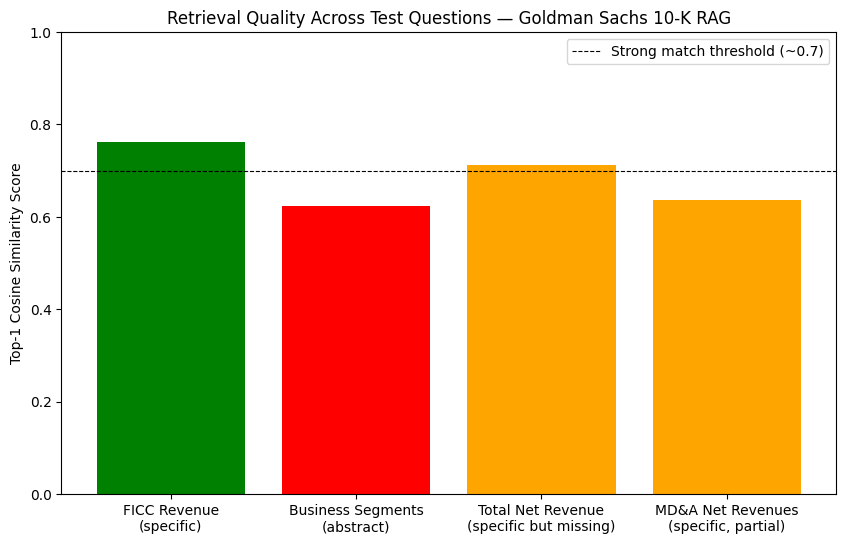

In [ ]:
questions_summary = ['FICC Revenue\n(specific)', 'Business Segments\n(abstract)',
                      'Total Net Revenue\n(specific but missing)', 'MD&A Net Revenues\n(specific, partial)']
top_scores = [0.763, 0.624, 0.713, 0.636]  # your top-1 score from each test

plt.figure(figsize=(10,6))
colors = ['green', 'red', 'orange', 'orange']
plt.bar(questions_summary, top_scores, color=colors)
plt.axhline(y=0.7, color='black', linestyle='--', linewidth=0.8, label='Strong match threshold (~0.7)')
plt.ylabel('Top-1 Cosine Similarity Score')
plt.title('Retrieval Quality Across Test Questions — Goldman Sachs 10-K RAG')
plt.ylim(0, 1)
plt.legend()
plt.show()